In [1]:
## Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gibbs_sampling import (
    SampleMultivariate,
    GaussianSampleMultivariate,
    StudenttSampleMultivariate,
    BimodalSampleMultivariate,
    HeavisideSampleMultivariate,
)
from scipy.linalg import inv
from GPy.kern import RBF

In [2]:
## Get data
np.random.seed(43)
df = pd.read_csv('heights_training_data.csv',index_col=0)
train, test = df.copy(), df.copy()
test.sort_values("log GDP per capita", inplace=True)

class Scaler:
    def __init__(self, for_uncertainties=False):
        self.for_uncertainties = for_uncertainties

    def fit(self, X: np.ndarray):
        self.means, self.stds = X.mean(axis=0), X.std(axis=0)

    def transform(self, X: np.ndarray):
        if self.for_uncertainties:
            return X / self.stds
        else:
            return (X - self.means) / self.stds

    def fit_transform(self, X: np.ndarray):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X: np.ndarray):
        if self.for_uncertainties:
            return X * self.stds
        else:
            return X * self.stds + self.means


scaler_x, scaler_y, scaler_y_unc = (
    Scaler(),
    Scaler(),
    Scaler(for_uncertainties=True),
)

train_X, train_y = train.iloc[:, :-1].to_numpy(), train.iloc[:, -1:].to_numpy()
test_X, test_y = test.iloc[:, :-1].to_numpy(), test.iloc[:, -1:].to_numpy()

train_X, train_y_temp = scaler_x.fit_transform(train_X), scaler_y.fit_transform(train_y)
scaler_y_unc.fit(train_y)
train_y = train_y_temp
test_X, test_y = scaler_x.transform(test_X), scaler_y.transform(test_y)

no_gender_train_X = np.delete(train_X, 0, axis=1)
no_gender_test_X = np.delete(test_X, 0, axis=1)

# diagonal noise parameter
noise_level = 0.8565

In [3]:
## Helper functions

def generate_exp_unc_given_kernel(
    kernel,
    training_X: np.ndarray,
    testing_X: np.ndarray,
    training_y: np.ndarray,
    # noise_level: float = 1.0,
    noise_level: float = 0.2,
):
    Sigma_yy = kernel(training_X) + np.diag([noise_level] * training_X.shape[0])
    inv_Sigma_yy = inv(Sigma_yy)
    Sigma_ff = kernel(testing_X)
    Sigma_fy = kernel(testing_X, training_X)
    Sigma_fy_dot_inv_Sigma_yy_dot_y = Sigma_fy @ inv_Sigma_yy @ training_y
    schur_Sigma_yy = Sigma_ff - Sigma_fy @ inv_Sigma_yy @ Sigma_fy.T
    y_squared = (training_y.reshape(1, -1) @ inv_Sigma_yy @ training_y).flatten()[0]

    distribution_expectation = Sigma_fy_dot_inv_Sigma_yy_dot_y.copy()
    distribution_covariance = schur_Sigma_yy.copy()
    distribution_covariance += np.diag([noise_level] * training_X.shape[0])

    return distribution_expectation, distribution_covariance, y_squared

In [4]:
## optimised parameters for distributions
gaussian_parameters = {"lengthscale": 3, "loglikelihood": -495.4033272815092}
studentt_parameters = {
    "nu": 500,
    "lengthscale": 3,
    "loglikelihood": -467.67141434,
}
bimodal_parameters = {
    "n": 0.001,
    "lengthscale": 3,
    "loglikelihood": -242.46465494,
}
heaviside_parameters = {
    "n": 50 + len(no_gender_train_X),
    "lengthscale": 2,
    "loglikelihood": -649.26087816,
}

In [5]:
## Data for each distribution
gaussian_expectation, gaussian_covariance, gaussian_ysquared = (
    generate_exp_unc_given_kernel(
        RBF(
            input_dim=no_gender_train_X.shape[1],
            lengthscale=gaussian_parameters["lengthscale"],
        ).K,
        no_gender_train_X,
        no_gender_test_X,
        train_y,
        noise_level=noise_level,
    )
)
studentt_expectation, studentt_covariance, studentt_ysquared = (
    generate_exp_unc_given_kernel(
        RBF(
            input_dim=no_gender_train_X.shape[1],
            lengthscale=studentt_parameters["lengthscale"],
        ).K,
        no_gender_train_X,
        no_gender_test_X,
        train_y,
        noise_level=noise_level,
    )
)
bimodal_expectation, bimodal_covariance, bimodal_ysquared = (
    generate_exp_unc_given_kernel(
        RBF(
            input_dim=no_gender_train_X.shape[1],
            lengthscale=bimodal_parameters["lengthscale"],
        ).K,
        no_gender_train_X,
        no_gender_test_X,
        train_y,
        noise_level=noise_level,
    )
)
heaviside_expectation, heaviside_covariance, heaviside_ysquared = (
    generate_exp_unc_given_kernel(
        RBF(
            input_dim=no_gender_train_X.shape[1],
            lengthscale=heaviside_parameters["lengthscale"],
        ).K,
        no_gender_train_X,
        no_gender_test_X,
        train_y,
        noise_level=noise_level,
    )
)
## Storage
list_of_distributions: dict[str, SampleMultivariate] = {
    "Gaussian": GaussianSampleMultivariate(
        gaussian_expectation, gaussian_covariance, noise_level=noise_level
    ),
    "Student \emph{t}": StudenttSampleMultivariate(
        studentt_expectation,
        studentt_covariance
        * (studentt_parameters["nu"] + studentt_ysquared)
        / (studentt_parameters["nu"] + len(no_gender_train_X)),
        studentt_parameters["nu"] + len(no_gender_train_X),
        noise_level=noise_level,
    ),
    "Bimodal": BimodalSampleMultivariate(
        bimodal_expectation,
        bimodal_covariance,
        bimodal_parameters["n"] + bimodal_ysquared - len(no_gender_train_X),
        noise_level=noise_level,
    ),
    "Heaviside": HeavisideSampleMultivariate(
        heaviside_expectation,
        heaviside_covariance
        * (heaviside_parameters["n"] - heaviside_ysquared)
        / (heaviside_parameters["n"] - len(no_gender_train_X)),
        heaviside_parameters["n"] - len(no_gender_train_X),
        noise_level=noise_level,
    ),
}


Running  Gaussian


Running  Student \emph{t}


Running  Bimodal


Running  Heaviside



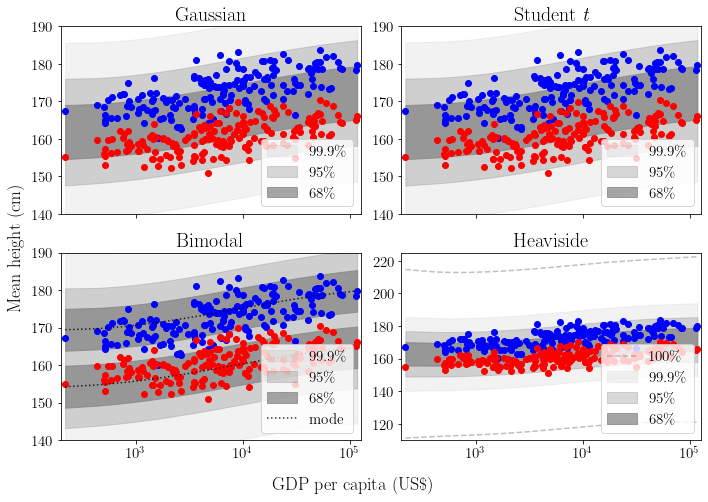

In [6]:
## Plot
fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(10, 7), sharex=True, sharey=False
)
boys_mask = test_X[:, 0] > 0

for ax, (name, sampler) in zip(axes.flatten(), list_of_distributions.items()):
    print("")
    print("Running ", name)
    print("")
    ax.set_title(name, fontsize=20)
    ax.tick_params(axis="y", which="major", labelsize=15)
    ax.set_ylim(140, 190)

    expectation = sampler.μ

    if name == "Heaviside":
        quantile_100 = sampler.quantiles(1)
        # print(scaler_y.inverse_transform(quantile_100[:, 0].reshape(-1, 1)))
        ax.plot(
            scaler_x.inverse_transform(test_X)[:, 1],
            scaler_y.inverse_transform(quantile_100[:, 0].reshape(-1, 1)).flatten(),
            color="grey",
            alpha=0.5,
            ls="--",
        )
        ax.plot(
            scaler_x.inverse_transform(test_X)[:, 1],
            scaler_y.inverse_transform(quantile_100[:, 1].reshape(-1, 1)).flatten(),
            color="grey",
            alpha=0.5,
            ls="--",
            label="100\%",
        )
        ax.set_ylim(110, 225)

    for quantile, alpha, precision in zip(
        [0.999, 0.95, 0.68], [0.1, 0.3, 0.7], [1, 0, 0]
    ):
        quantile_values = sampler.quantiles(quantile)
        ax.fill_between(
            scaler_x.inverse_transform(test_X)[:, 1],
            scaler_y.inverse_transform(
                quantile_values[:, 0].reshape(-1, 1)
            ).flatten(),
            scaler_y.inverse_transform(
                quantile_values[:, 1].reshape(-1, 1)
            ).flatten(),
            color="grey",
            alpha=alpha,
            label=f"{quantile*100:.{precision}f}\%",
        )
        if quantile_values.shape[1] > 2:
            ax.fill_between(
                scaler_x.inverse_transform(test_X)[:, 1],
                scaler_y.inverse_transform(
                    quantile_values[:, 2].reshape(-1, 1)
                ).flatten(),
                scaler_y.inverse_transform(
                    quantile_values[:, 3].reshape(-1, 1)
                ).flatten(),
                color="grey",
                alpha=alpha,
            )
    if name == "Bimodal":
        ax.plot(
            scaler_x.inverse_transform(test_X)[:, 1],
            scaler_y.inverse_transform(
                (sampler.μ.reshape(-1) - sampler.mode_offset).reshape(-1, 1)
            ).flatten(),
            color="black",
            alpha=0.8,
            ls=":",
            label="mode",
        )
        ax.plot(
            scaler_x.inverse_transform(test_X)[:, 1],
            scaler_y.inverse_transform(
                (sampler.μ.reshape(-1) + sampler.mode_offset).reshape(-1, 1)
            ).flatten(),
            color="black",
            alpha=0.8,
            ls=":",
        )

    ax.scatter(
        scaler_x.inverse_transform(test_X[boys_mask])[:, 1],
        scaler_y.inverse_transform(test_y[boys_mask].reshape(-1, 1)),
        c="b",
    )
    ax.scatter(
        scaler_x.inverse_transform(test_X[~boys_mask])[:, 1],
        scaler_y.inverse_transform(test_y[~boys_mask].reshape(-1, 1)),
        c="r",
    )

    ax.set_xlim(2.3, 5.1)
    # ax.set_ylim(140, 190)
    ax.set_xticks([3.0, 4.0, 5.0], ["$10^3$", "$10^4$", "$10^5$"], fontsize=15)
    # ax.set_yticks([150, 160, 170, 180], [150, 160, 170, 180], fontsize=15)
    ax.legend(loc="lower right", fontsize=15)

fig.supxlabel("GDP per capita (US\$)", fontsize=18)
fig.supylabel("Mean height (cm)", fontsize=18)

plt.tight_layout()
plt.show()